# Bevezetés

Ez a notebook a meglévő PM2.5 forecasting pipeline neurális háló alapú kiegészítésének tesztelését és kiértékelését mutatja be. A cél annak vizsgálata, hogy a korábban használt regressziós modellekhez képest javítható-e az előrejelzés neurális háló alkalmazásával.

## Importok

A szükséges könyvtárak betöltése:

1. Használt modellek: RandomForestRegressor, HistGradientBoostingRegressor, LGBMRegressor, XGBRegressor, Ridge
2. Pipeline: scikit-learn pipeline lehetőség
3. SimpleImputer: NAN-ok kezelésére
4. pandas, numpy: adatkezelés
5. joblib: adatmentés, betöltés
6. sklearn.metrics: metrikákhoz
7. matplotlib: vizualizáció
8. os: fájl meglétének ellenőrzéséhez
9. standardscaler: adatok skálázásához
10. tensorflow: Neurális háló implementáláshoz

In [1]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

## Log target kapcsoló

A több tesztelési lehetőség érdekében a log target át és vissza alakítás állíthatóvá tesszük.

In [2]:
USE_LOG_TARGET = False

def transform_target(y):
    return np.log1p(y) if USE_LOG_TARGET else y

def inverse_target(y):
    return np.maximum(0, np.expm1(y)) if USE_LOG_TARGET else y


## Adatok betöltése

In [3]:
train = pd.read_parquet("../data/preprocessed/train.parquet")
test  = pd.read_parquet("../data/preprocessed/test.parquet")
FEATURES = joblib.load("../artifacts/features.pkl")
LOCATION_MAPPING = joblib.load("../artifacts/location_mapping.pkl")
ENSEMBLE_PATH = "../models/models_ensemble.pkl"

train = train.sort_values(["location", "datetime"])
test  = test.sort_values(["location", "datetime"])

train["pm25_next"] = train.groupby("location")["pm25"].shift(-1)
test["pm25_next"]  = test.groupby("location")["pm25"].shift(-1)

## NAN-ok törlése

In [4]:
TARGET = "pm25_next"

columns = [
    "pm25_next",
    "pm25_lag1",
    "pm25_lag3",
    "pm25_lag6",
    "pm25_lag24",
    "pm25_roll6",
    "pm25_roll24",
    "pm25_trend_3h",
    "pm25_std_12h",
    "temp_change_3h",
    "humidity_change_3h",
    "wind_change_3h",
    "stagnation_hours_6h"
]

train = train.dropna(subset=columns)
test  = test.dropna(subset=columns)

## Train és teszt adatok létrehozása

In [5]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

y_train_used = transform_target(y_train)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (34836, 34)
Test : (22125, 34)


## Model paraméterezés

In [6]:
models = {
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=715,
            max_depth=16,
            min_samples_split=9,
            min_samples_leaf=3,
            max_features=None,
            random_state=42
        ))
    ]),

    "HistGB": Pipeline([
        ("model", HistGradientBoostingRegressor(
            max_iter=309,
            learning_rate=0.052392441315122884,
            max_depth=6,
            min_samples_leaf=89,
            l2_regularization=0.10712858441423956,
            max_bins=172,
            random_state=42
        ))
    ]),

    "LGBM": Pipeline([
        ("model", LGBMRegressor(
            n_estimators=723,
            learning_rate=0.012885472793169907,
            max_depth=11,
            num_leaves=71,
            subsample=0.6904437214202783,
            colsample_bytree=0.6924371848724423,
            random_state=42
        ))
    ]),

    "XGB": Pipeline([
        ("model", XGBRegressor(
            n_estimators=615,
            learning_rate=0.08447106507617709,
            max_depth=3,
            subsample=0.9593316490919434,
            colsample_bytree=0.743423049049403,
            random_state=42
        ))
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.01007089724896645))
    ]),
}

print("\nTraining models...")
results = []
trained_models = {}


Training models...


## BASELINE (lag1)

Baselinenak az egy órával korábbi PM2.5 értéket állítjuk be az összehasonlításhoz.

In [7]:
baseline_pred = X_test["pm25_lag1"]

results.append({
    "model": "Baseline_lag1",
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "R2": r2_score(y_test, baseline_pred)
})


## Sklearn models

Sklearn modellek tanítása.

In [8]:
for name, model in models.items():
    
    model.fit(X_train, y_train_used)
    trained_models[name] = model
    
    pred_raw = model.predict(X_test)
    pred = inverse_target(pred_raw)
    
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5216
[LightGBM] [Info] Number of data points in the train set: 34836, number of used features: 34
[LightGBM] [Info] Start training from score 16.810160


## Neural network implementáció

A jobb paraméterezhetőség érdekében a neurális hálót külön implementáljuk.

### Kipróbált paraméterek

| Paraméter | Kipróbált értékek | Rövid leírás |
|---|---|---|
| Imputálás | median imputer | Hiányzó értékek pótlása |
| Scaler | StandardScaler | Feature-ök normalizálása |
| Rétegek száma | 3-4 | Modell mélysége |
| Neuronok száma | 64-128 | Layer kapacitás |
| Activation | ReLU, LeakyReLU, Swish, GELU | Nemlinearitás |
| Dropout | 0.5 | Overfitting csökkentése |
| BatchNormalization | használva | Stabilabb tanítás |
| Learning rate | 0.001, 0.0001 | Tanulási sebesség |
| Loss | MAE, MSE | Optimalizált hibafüggvény |
| Epochs | 100-300 | Maximális tanítási ciklus |
| Batch size | 128-256 | Batch méret |
| Early stopping | patience alapú | Overfitting megelőzés |

### Legjobb konfiguráció

| Paraméter | Legjobb érték |
|---|---|
| Imputálás | SimpleImputer(strategy="median") |
| Scaler | StandardScaler |
| Rétegek | 3 |
| Neuronok | 64 → 32 |
| Activation | Swish |
| Dropout | nem hozott javulást |
| BatchNormalization | igen |
| Learning rate | 0.0001 |
| Loss | MAE |
| Epochs | EarlyStopping által megállítva |
| Batch size | 256 |
| Early stopping | patience=5 |

In [9]:
# SPLIT a nyers adatokon

val_ratio = 0.2
n = len(X_train)
split = int(n * (1 - val_ratio))

X_tr_raw = X_train.iloc[:split]
X_val_raw = X_train.iloc[split:]

y_tr = y_train_used.values[:split]
y_val = y_train_used.values[split:]


# IMPUTER (csak trainen fit)
imputer = SimpleImputer(strategy="median")

X_tr_imp = imputer.fit_transform(X_tr_raw)
X_val_imp = imputer.transform(X_val_raw)


# SCALER (csak trainen fit)
scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr_imp)
X_val = scaler.transform(X_val_imp)


nn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1, activation = 'linear')
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = "mae",
    metrics=[
        "mae",
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )
]

history = nn_model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 14.5800 - mae: 14.5800 - rmse: 20.0950 - val_loss: 25.6765 - val_mae: 25.6765 - val_rmse: 31.3719
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.4837 - mae: 14.4837 - rmse: 19.8868 - val_loss: 25.5703 - val_mae: 25.5703 - val_rmse: 31.1397
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.3751 - mae: 14.3751 - rmse: 19.7139 - val_loss: 25.4426 - val_mae: 25.4426 - val_rmse: 30.9215
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.2496 - mae: 14.2496 - rmse: 19.5789 - val_loss: 25.2589 - val_mae: 25.2589 - val_rmse: 30.6757
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.1070 - mae: 14.1070 - rmse: 19.4000 - val_loss: 24.9507 - val_mae: 24.9507 - val_rmse: 30.2877
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.9474 - mae: 13.9474 - rmse: 19.1981 - val_loss: 24.6775 - val_mae: 24.6775 - val_rmse: 29.9223
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

## Train

In [10]:
# Osztálylétrehozás kompatibilitás miatt
class NNWrapper:
    def __init__(self, model, imputer, scaler):
        self.model = model
        self.imputer = imputer
        self.scaler = scaler

    def predict(self, X):
        X_imp = self.imputer.transform(X)
        X_scaled = self.scaler.transform(X_imp)
        return self.model.predict(X_scaled, verbose=0).flatten()


nn_wrapper = NNWrapper(nn_model, imputer, scaler)

# TRAIN PRED
train_pred_raw = nn_wrapper.predict(X_train)
train_pred = inverse_target(train_pred_raw)

# TEST PRED
test_pred_raw = nn_wrapper.predict(X_test)
test_pred = inverse_target(test_pred_raw)


## Metrikák

In [11]:
print("\nTrain:")
print("MAE:", mean_absolute_error(y_train, train_pred))
print("R2 :", r2_score(y_train, train_pred))

print("\nTest:")
print("MAE:", mean_absolute_error(y_test, test_pred))
print("R2 :", r2_score(y_test, test_pred))

results.append({
    "model": "NeuralNet",
    "MAE": mean_absolute_error(y_test, test_pred),
    "R2": r2_score(y_test, test_pred)
})


Train:
MAE: 2.2443046866409513
R2 : 0.9164218218233415

Test:
MAE: 3.0434114502426706
R2 : 0.8490077864838315


## Loss görbe

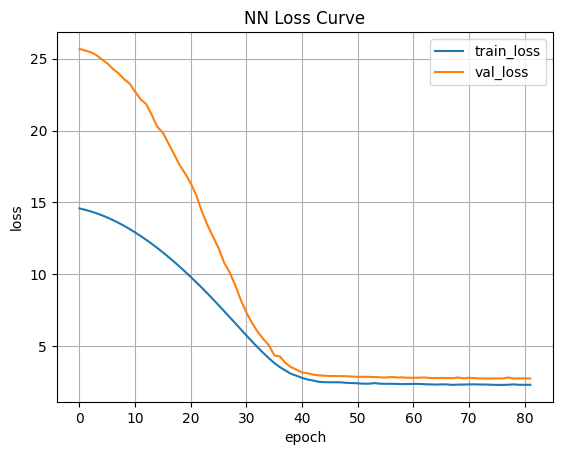

In [12]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("NN Loss Curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid()
plt.show()

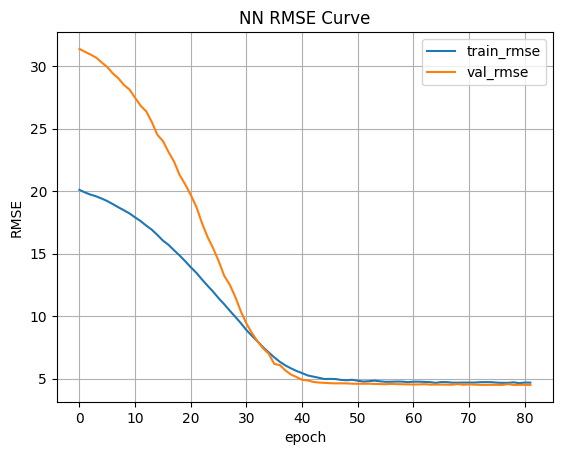

In [13]:
plt.figure()

plt.plot(history.history["rmse"], label="train_rmse")
plt.plot(history.history["val_rmse"], label="val_rmse")

plt.title("NN RMSE Curve")
plt.xlabel("epoch")
plt.ylabel("RMSE")

plt.legend()
plt.grid()

plt.show()

## Újratanítás (teljes trainen)

In [14]:
nn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1, activation='linear')
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mae"
)

imputer_full = SimpleImputer(strategy="median")
scaler_full = StandardScaler()

X_train_imp_full = imputer_full.fit_transform(X_train)
X_train_scaled_full = scaler_full.fit_transform(X_train_imp_full)

nn_model.fit(
    X_train_scaled_full,
    y_train_used.values,
    epochs = np.argmin(history.history["val_loss"]) + 1,
    batch_size=256,
    verbose=0
)

trained_models["NeuralNet"] = NNWrapper(nn_model, imputer_full, scaler_full)

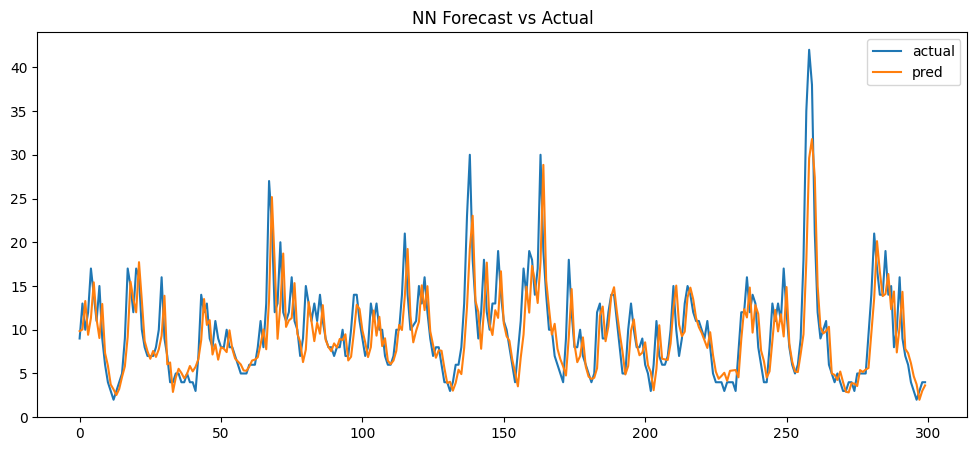

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:300], label="actual")
plt.plot(test_pred[:300], label="pred")

plt.legend()
plt.title("NN Forecast vs Actual")

plt.show()

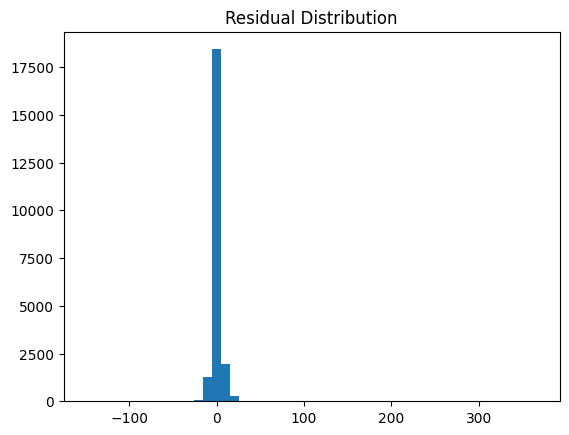

In [16]:
residuals = y_test.values - test_pred

plt.figure()
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")

plt.show()

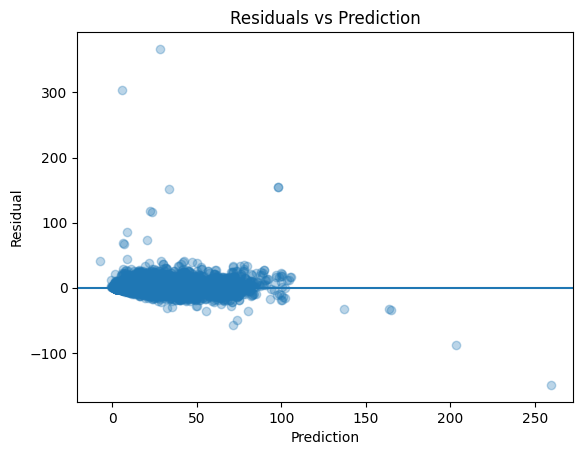

In [17]:
plt.figure()
plt.scatter(test_pred, residuals, alpha=0.3)
plt.axhline(0)

plt.xlabel("Prediction")
plt.ylabel("Residual")

plt.title("Residuals vs Prediction")

plt.show()

## Ensemble (ha létezik)

In [18]:
if os.path.exists(ENSEMBLE_PATH):

    print("\nEvaluating existing ensemble...")

    ensemble_models = joblib.load(ENSEMBLE_PATH)

    preds = []

    for name, model in ensemble_models.items():

        pred_raw = model.predict(X_test)

        pred = inverse_target(pred_raw)
        preds.append(pred)

    ensemble_pred = np.mean(preds, axis=0)

    results.append({
        "model": "ENSEMBLE",
        "MAE": mean_absolute_error(y_test, ensemble_pred),
        "R2": r2_score(y_test, ensemble_pred)
    })


Evaluating existing ensemble...


## Eredmények

Top models: ['NeuralNet', 'Ridge']
           model       MAE        R2
7       ENSEMBLE  2.987495  0.844147
6      NeuralNet  3.043411  0.849008
5          Ridge  3.075772  0.833880
3           LGBM  3.203882  0.839078
1   RandomForest  3.238492  0.841366
4            XGB  3.243402  0.835939
2         HistGB  3.246547  0.835936
0  Baseline_lag1  4.531578  0.700562


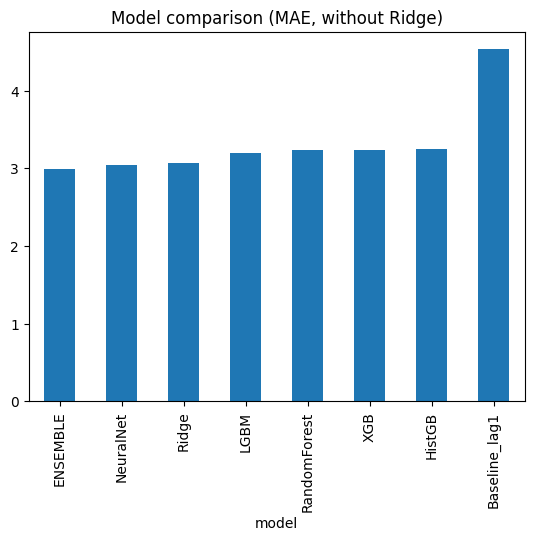

In [19]:
results_df = pd.DataFrame(results).sort_values("MAE")

top_models = (
    results_df[results_df["model"] != "ENSEMBLE"]
    .head(2)["model"]
    .tolist()
)

print("Top models:", top_models)
print(results_df)

results_df.set_index("model")["MAE"].plot.bar()
plt.title("Model comparison (MAE, without Ridge)")
plt.show()

## Model mentése

In [20]:
best_model_name = results_df.iloc[0]["model"]

if best_model_name == "ENSEMBLE":
    best_model = ensemble_models
else:
    best_model = trained_models[best_model_name]

joblib.dump(best_model, "../models/model.pkl")
print(f"Best model = {best_model_name} saved.")

top_trained_models = {
    name: trained_models[name]
    for name in top_models
}

joblib.dump(top_trained_models, ENSEMBLE_PATH)
print("Top-2 ensemble saved.")

Best model = ENSEMBLE saved.
Top-2 ensemble saved.


## Megfigyelések

A tesztek során a Ridge hozta a legstabilabb eredményeket.  
A modell különösen jól teljesített:

- log target transzformáció nélkül
- median imputálással
- StandardScaler normalizálással

A lineáris modell meglepően versenyképesnek bizonyult ennél a feladatnál a komplexebb ensemble és neurális háló modellel szemben.

---

## Neurális háló tapasztalatok

Az ANN modell bizonyos konfigurációk mellett kis mértékű MAE javulást mutatott, walkforward validációnál stabilabb eredményt adott nagyobb horizonton, azonban recursive forecasting környezetben több probléma is jelentkezett:

- érzékenyebb distribution shiftre
- érzékenyebb hiányzó adatokra
- NaN cascade hatás recursive rollout során
- autoregresszív előrejelzésnél fokozatos drift
- hosszabb horizonton stabilitási problémák, de ez a recursive hibahalmozódás miatt a többi modellre is igaz

A neurális háló különösen érzékeny volt arra az esetre, amikor a legutolsó PM2.5 mérési érték hiányzott. Mivel a lag feature-ök erre épülnek, egyetlen NaN érték a teljes recursive forecasting folyamatot instabillá tehette.

---

## Következtetés

Bár a neurális háló bizonyos esetekben alacsonyabb hibát tudott elérni, a recursive multi-step forecasting stabilitása szempontjából a klasszikus regressziós modellek — különösen a Ridge és az ensemble megoldások — robusztusabbnak bizonyultak. Azonban az említett problémák megfelelő kezelésével komplexebb, de pontosabb megoldást kaphatunk.

Walkforward eredmény

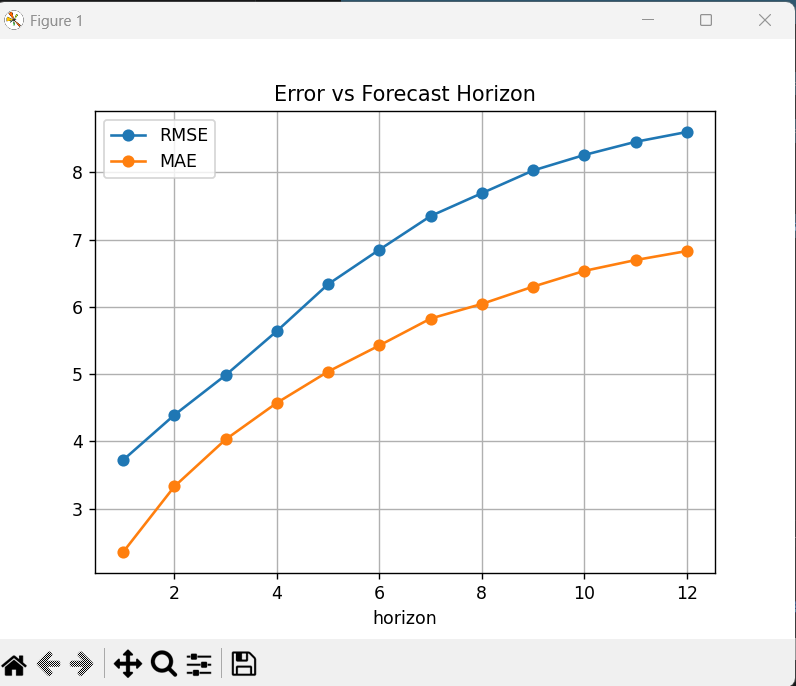